# Neural Network Example

This notebook illustrates how to setup and train a neural network using PyTorch.

## Wine Quality Dataset

We will use a dataset which was set up to study dependence of wine quality on physical and chemical properties measured during wine production. The dataset covers ~1600 wine samples of red Vinho Verde (a Portuguese wine), and includes measurements of 11 physicochemical properties, together with a subjective wine quality mark (out of 10) assigned by an expert wine taster.

You can download the dataset here : https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

The dataset is discussed further in https://doi.org/10.1016/j.dss.2009.05.016

We will create a very simple neural network, and train it to predict the quality mark from the physicochemical measurements. (This is a regression problem).

First we load the dataset using Pandas

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('winequality-red.csv')
print(df)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

 Before we start, we can examine some of the variables using pandas

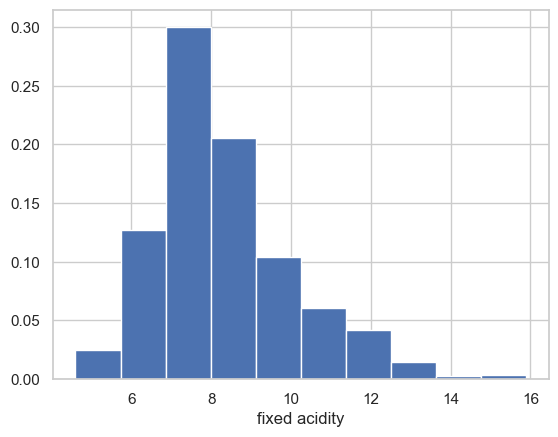

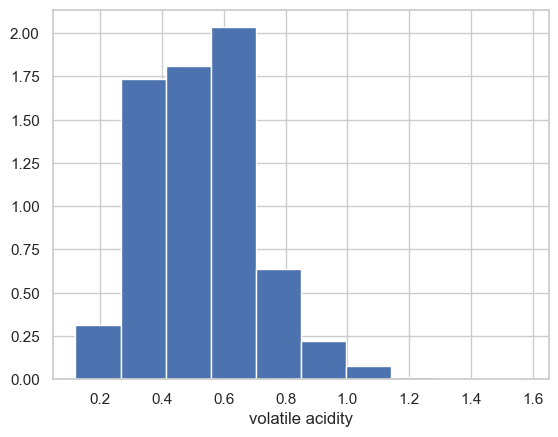

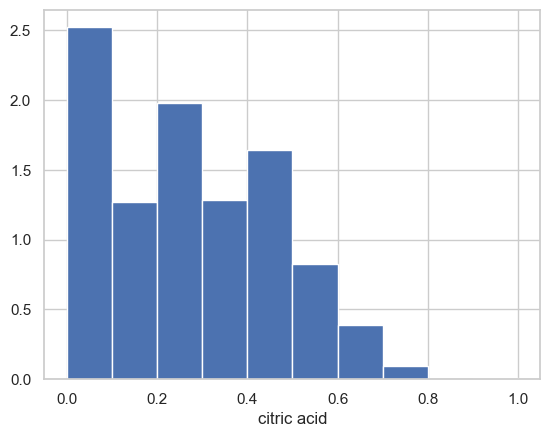

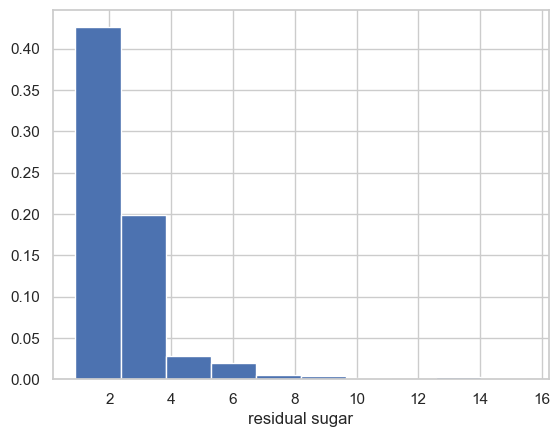

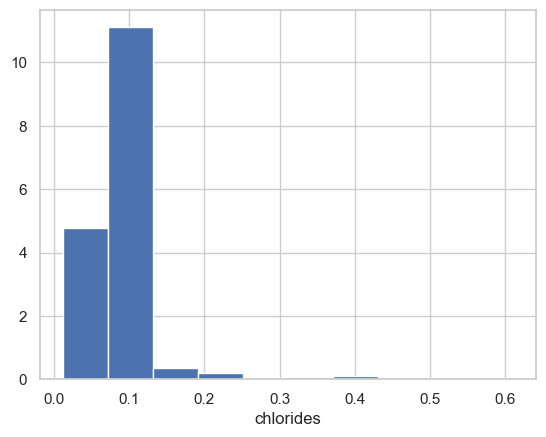

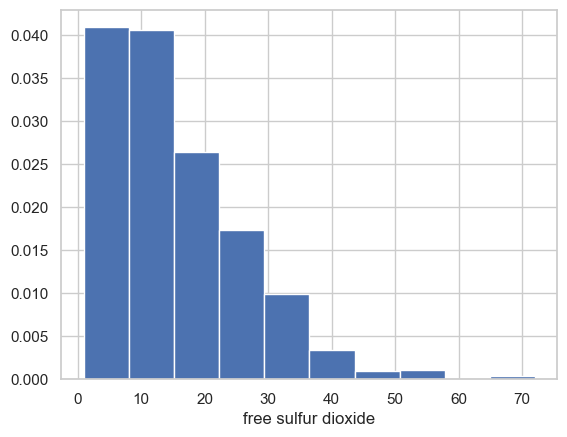

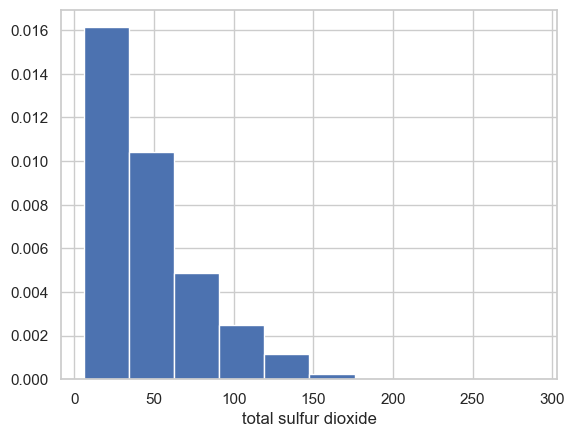

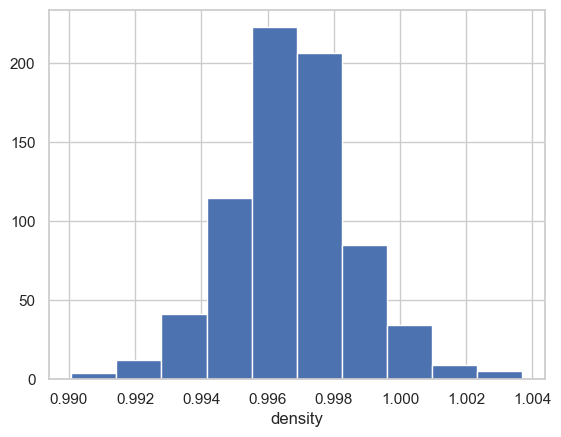

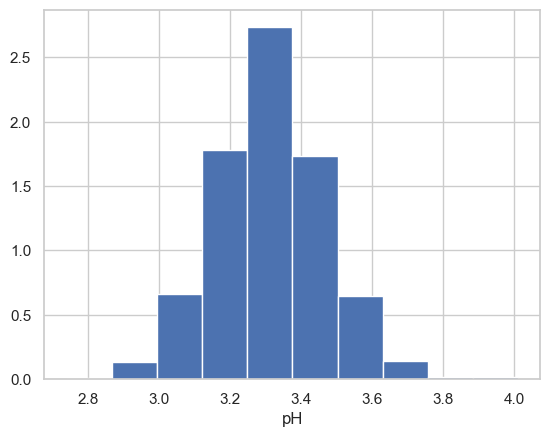

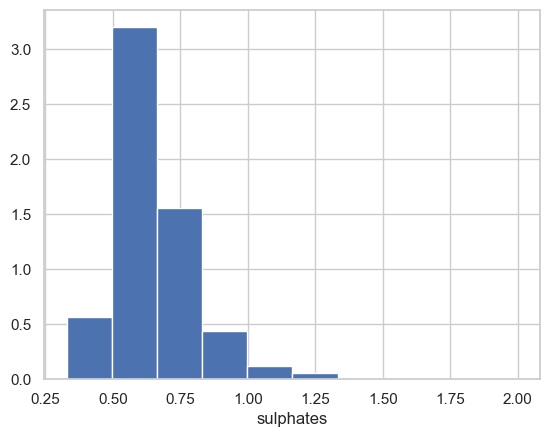

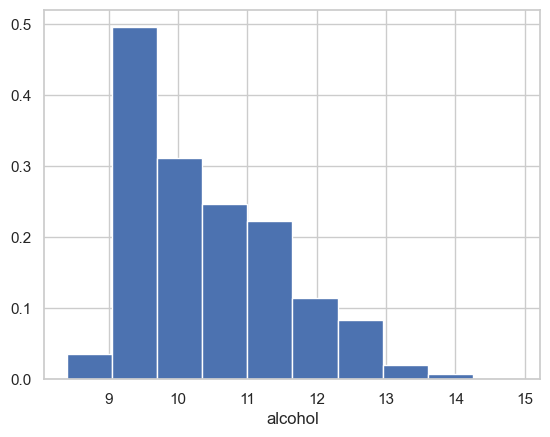

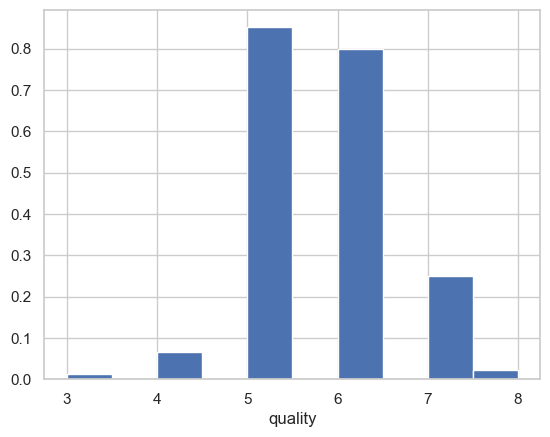

In [2]:
# distribution of some variables

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
sns.set_style("whitegrid")

for col in df.columns:
    
    plt.hist(df[col], density=True)
    plt.xlabel(col)
    plt.savefig(col+".pdf")
    plt.show()



## PyTorch formats

Now we convert the data into PyTorch formats. First we convert the pandas data frame to a PyTorch Tensor. We then use PyTorch utilities to split this into training and validation datasets.  We also create DataLoaders, which are the PyTorch utility for managing batches etc.

In [56]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

# input / output dataframe columns
input_cols = list(df.columns)[:-1]
output_cols = ['quality']

# create Torch tensors
X_data = torch.Tensor(df[input_cols].to_numpy())
y_data = torch.Tensor(df[output_cols].to_numpy())

# create Torch dataset
dataset = TensorDataset(X_data, y_data)

# create train and validation datasets
val_size   = int(0.2*len(df))
train_size = len(df)-val_size
print("Training dataset size   :", train_size)
print("Validation dataset size :", val_size)

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, shuffle=False, batch_size=16)
val_loader = DataLoader(val_data, shuffle=False)

Training dataset size   : 1280
Validation dataset size : 319


## Model

Next we define the model.  This is a single layer Neural Network the output of which is a linear sum.  Note that this is basically an 11D linear regression problem.  However, once you have run the notebook as it stands, you can try creating a more complex network - for example, add one or two hidden layers with (say) 64 nodes using ReLU activation functions.


In [57]:
import torch.nn as nn
import torch.nn.functional as F

class SingleLayerNNModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        # Here we create the model itself
        # This is just a single layer with 11 inputs (and weights) and 1 output
        #self.layers = nn.Linear(11, 1)

        # here is an alternative, a real neural network with a hidden layer
        self.layers = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
        
    def forward(self, xb):
        # compute the forward pass
        out = self.layers(xb)
        return out

    def training_step(self, batch):
        # a training step means computing the output from a batch
        x, y = batch
        y_hat = self(x)
        # then computing the loss
        # here we use the mean absolute loss
        loss = F.l1_loss(y_hat, y)
        return loss

Next we define a class which will help with training the model.  This class will setup an optimizer, run over a defined number of epochs, storing the losses (for both training and validation samples).

In [73]:
class Trainer():
    def __init__(self, model, n_epochs, lr, train_loader, val_loader):
        self.model = model
        self.n_epochs = n_epochs
        self.loss_train = np.zeros(n_epochs)
        self.loss_val   = np.zeros(n_epochs)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=lr)
        #self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        print(self.train_loader)
        
    def fit(self):
        for epoch in range(self.n_epochs):

            # this is the training phase
            loss_t = []
            for batch in self.train_loader:
                loss = self.model.training_step(batch)
                loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()
                loss_t.append(loss.item())
            self.loss_train[epoch] = np.array(loss_t).mean()

            # this is the validation phase
            # just calculate the loss, no updating weights !
            loss_v = []
            for batch in self.val_loader:
                loss = self.model.training_step(batch).item()
                loss_v.append(loss)
            self.loss_val[epoch] = np.array(loss_v).mean()
            
            # add some printout every few epochs
            if (epoch+1) % 20 == 0 or epoch == self.n_epochs-1:
                print("Epoch [{}], val_loss: {:.4f}".format(epoch+1, self.loss_val[epoch]))

## Training

Now we create the model and test that we can also compute the loss...

The training parameters below should be reasonable, but you can see what happens if you increase the learning rate, and/or number of epochs.

In [74]:
# create the model
model = SingleLayerNNModel()

trainer = Trainer(model, 500, 1e-4, train_loader, val_loader)
trainer.fit()

Epoch [20], val_loss: 0.5396
Epoch [40], val_loss: 0.5223
Epoch [60], val_loss: 0.5139
Epoch [80], val_loss: 0.5131
Epoch [100], val_loss: 0.5137
Epoch [120], val_loss: 0.5135
Epoch [140], val_loss: 0.5137
Epoch [160], val_loss: 0.5137
Epoch [180], val_loss: 0.5137
Epoch [200], val_loss: 0.5139
Epoch [220], val_loss: 0.5142
Epoch [240], val_loss: 0.5138
Epoch [260], val_loss: 0.5144
Epoch [280], val_loss: 0.5145
Epoch [300], val_loss: 0.5144
Epoch [320], val_loss: 0.5149
Epoch [340], val_loss: 0.5147
Epoch [360], val_loss: 0.5150
Epoch [380], val_loss: 0.5144
Epoch [400], val_loss: 0.5145
Epoch [420], val_loss: 0.5151
Epoch [440], val_loss: 0.5145
Epoch [460], val_loss: 0.5156
Epoch [480], val_loss: 0.5150
Epoch [500], val_loss: 0.5157


Next plot the loss(es) as a function of epoch.  This shows the model has been trained, and is not behvaing badly (eg. overfitting).

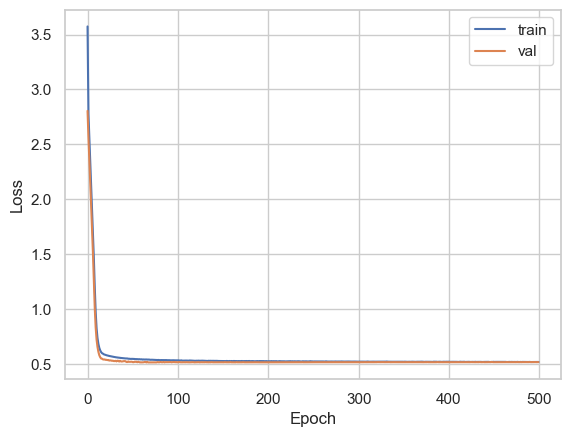

In [75]:
import matplotlib.pyplot as plt

x = np.arange(0,trainer.n_epochs)

plt.plot(x, trainer.loss_train, label="train")
plt.plot(x, trainer.loss_val, label="val")
#plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss.pdf")
plt.show()

## Model Performance

Finally, we can make predictions of quality for a given wine sample wihtin the validation dataset.

In [67]:
def predict_single(input, target, model):
    inputs = input.unsqueeze(0) 
    predictions = model(inputs)
    prediction = predictions[0].detach()
    print("X:", input)
    print("y:", target)
    print("y_hat:", prediction)

input, target = val_data[3]
predict_single(input, target, model)

input, target = val_data[9]
predict_single(input, target, model)

X: tensor([ 6.8000,  0.7700,  0.0000,  1.8000,  0.0660, 34.0000, 52.0000,  0.9976,
         3.6200,  0.6800,  9.9000])
y: tensor([5.])
y_hat: tensor([5.4023])
X: tensor([ 6.7000,  0.5800,  0.0800,  1.8000,  0.0970, 15.0000, 65.0000,  0.9959,
         3.2800,  0.5400,  9.2000])
y: tensor([5.])
y_hat: tensor([4.9633])


Now let's look at some performance metrics.  We already computed the mean absolute error, since we have used that in the loss.  We can see from the plot above that, on the validation dataset, we have achieved a mean absolute error of ~0.5833.  We can compute the $R^2$, but first we plot a scatter graph of true versus predicted values of quality.

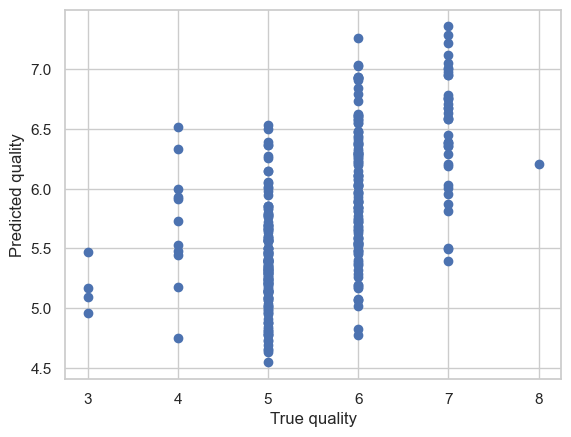

In [68]:
ys = []
y_hats = []
for batch in val_loader:
    x, y = batch
    ys.append(y.item())
    y_hats.append(model(x).detach().item())

plt.scatter(ys, y_hats)
plt.xlabel("True quality")
plt.ylabel("Predicted quality")
plt.savefig("pred-vs-true.pdf")
plt.show()

Or as a violin plot

/var/folders/8w/47ff1svj2slgfs3h0xfkvb9c0000gp/T/ipykernel_66047/3630279821.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["2", "3", "4", "5", "6", "7", "8"])


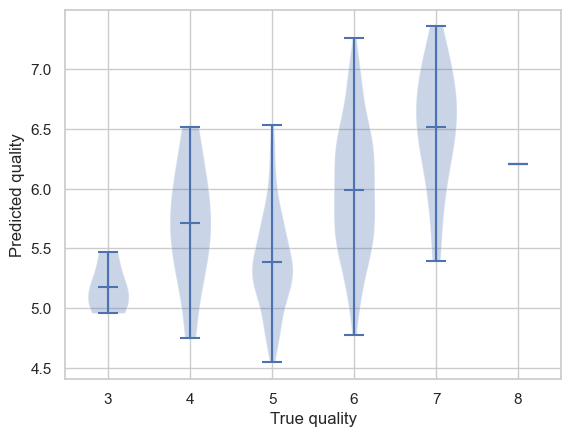

In [69]:
yh = np.array(y_hats)
y = np.array(ys)
all_data = [ yh[y==3], yh[y==4], yh[y==5], yh[y==6], yh[y==7], yh[y==8] ]

fig, ax = plt.subplots()

plt.violinplot(all_data, showmeans=True)
plt.xlabel("True quality")
ax.set_xticklabels(["2", "3", "4", "5", "6", "7", "8"])
plt.ylabel("Predicted quality")
plt.savefig("violin.pdf")
plt.show()

Now we can calculate the $R^2$

In [70]:
y_var = np.var(ys)
n = len(ys)

sum_res = 0
for y,y_hat in zip(ys,y_hats):
    sum_res += (y-y_hat)**2
sum_res /= n

print("var(y)  :", y_var)
print("sum_res :", sum_res)
print("R^2     :",1 - sum_res/y_var)

var(y)  : 0.647124143827203
sum_res : 0.4871150380026142
R^2     : 0.24726183893907516


Which is not great, this is saying the model can account for about 20% of the variance in true values of quality.